# Tests de performance système — Modèle `sig`

Ce notebook mesure les performances du pipeline de prédiction `sig` (imputation → scaling → Isolation Forest → RandomForestRegressor) selon quatre axes :

| Métrique | Description |
|---|---|
| **Latence** | Temps pour produire une prédiction sur un seul exemple |
| **Débit** | Nombre de prédictions par seconde |
| **Empreinte mémoire** | Occupation RAM en fonction de la taille du batch |
| **Tests de charge / stress** | Comportement jusqu'à et au-delà de la charge nominale |

## 1. Imports et configuration

In [1]:
import sys
import time
import tracemalloc
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil

warnings.filterwarnings("ignore")

# --- Chemins ---
NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
SCRIPTS_DIR  = PROJECT_ROOT / "scripts"
DATA_DIR     = PROJECT_ROOT / "data"
ARTIFACTS_DIR = PROJECT_ROOT / "models" / "imputation"

# Rendre le script importable
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

from predict_sig import predict, load_artifacts, DEFAULT_THRESHOLD, COLUMNS_TO_DROP

print(f"PROJECT_ROOT  : {PROJECT_ROOT}")
print(f"ARTIFACTS_DIR : {ARTIFACTS_DIR}")
print(f"Seuil IF par défaut : {DEFAULT_THRESHOLD}")

PROJECT_ROOT  : /home/camille/code/Camille9999/EPSI/M2/EPSI_atelier-info-doc_projet
ARTIFACTS_DIR : /home/camille/code/Camille9999/EPSI/M2/EPSI_atelier-info-doc_projet/models/imputation
Seuil IF par défaut : -0.618


In [2]:
# Chargement des artefacts (une seule fois)
artifacts = load_artifacts(ARTIFACTS_DIR)
print("Artefacts chargés :", list(artifacts.keys()))

# Chargement du dataset brut
df_raw = pd.read_csv(DATA_DIR / "earthquake_data.csv")
N_TOTAL = len(df_raw)
print(f"\nDataset : {N_TOTAL} lignes × {df_raw.shape[1]} colonnes")
print(f"Taille en mémoire (CSV brut) : {df_raw.memory_usage(deep=True).sum() / 1024:.1f} Ko")

Artefacts chargés : ['feature_order', 'numeric_cols', 'categorical_cols', 'imputer_num', 'scaler', 'isolation_forest', 'model']

Dataset : 782 lignes × 19 colonnes
Taille en mémoire (CSV brut) : 416.8 Ko


## 2. Latence — temps pour une prédiction unique

On mesure le temps de bout en bout (imputation + scaling + IF + prédiction) sur **une seule ligne**.  
On répète 100 fois pour obtenir une distribution stable.

Latence sur 1 ligne (100 répétitions) :
  Médiane  : 23.331 ms
  Moyenne  : 40.335 ms
  Min      : 18.662 ms
  Max      : 202.465 ms
  p95      : 131.422 ms
  p99      : 188.360 ms


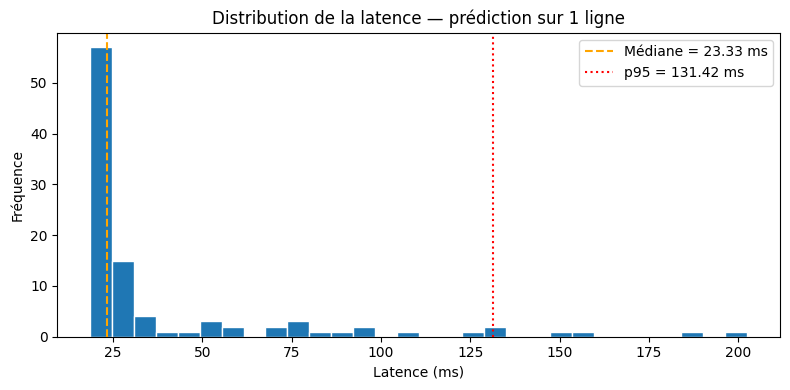

In [3]:
LATENCY_REPEATS = 100
single_row = df_raw.sample(1, random_state=42)

latencies_ms = []
for _ in range(LATENCY_REPEATS):
    t0 = time.perf_counter()
    predict(single_row, artifacts, threshold=DEFAULT_THRESHOLD, keep_anomalies=True)
    t1 = time.perf_counter()
    latencies_ms.append((t1 - t0) * 1000)

latencies_ms = np.array(latencies_ms)

print(f"Latence sur 1 ligne ({LATENCY_REPEATS} répétitions) :")
print(f"  Médiane  : {np.median(latencies_ms):.3f} ms")
print(f"  Moyenne  : {np.mean(latencies_ms):.3f} ms")
print(f"  Min      : {np.min(latencies_ms):.3f} ms")
print(f"  Max      : {np.max(latencies_ms):.3f} ms")
print(f"  p95      : {np.percentile(latencies_ms, 95):.3f} ms")
print(f"  p99      : {np.percentile(latencies_ms, 99):.3f} ms")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(latencies_ms, bins=30, color="#1f77b4", edgecolor="white")
ax.axvline(np.median(latencies_ms), color="orange", linestyle="--", label=f"Médiane = {np.median(latencies_ms):.2f} ms")
ax.axvline(np.percentile(latencies_ms, 95), color="red", linestyle=":", label=f"p95 = {np.percentile(latencies_ms, 95):.2f} ms")
ax.set_xlabel("Latence (ms)")
ax.set_ylabel("Fréquence")
ax.set_title("Distribution de la latence — prédiction sur 1 ligne")
ax.legend()
plt.tight_layout()
plt.show()

---
---
### Interprétation




- Le temps de traitement d'une seule ligne varie entre 18ms et 202ms. De plus, l’analyse de la latence sur une prédiction unitaire montre une médiane autour de 23ms, ce qui indique qu’en condition normale, le pipeline complet reste relativement rapide.
<br/>
- La majorité des exécutions se concentre entre environ 15 et 30 ms. Cependant, la moyenne (40.335 ms) est supérieure à la médiane, ce qui révèle une distribution asymétrique avec quelques valeurs extrêmes. Cette observation est confirmée par un p95 de 131.422 ms et un p99 de 188.360 ms.
<br/>
- On peut supposer que les valeurs extrêmes de latence correspondent probablement à des pics ponctuels liés à l’environnement d’exécution (OS, notebook, gestion mémoire), ou encore à des processus lancés en arrière plan.
<br/>
- Le système présente donc une latence satisfaisante, mais une variabilité non négligeable sur certains appels isolés.
---
---


## 3. Débit — prédictions par seconde

On mesure le temps total pour prédire des **batches de tailles croissantes** et on en déduit le débit (prédictions/s).

       1 lignes → 27.64 ms → 36 préd/s
      10 lignes → 29.46 ms → 339 préd/s
      50 lignes → 24.11 ms → 2,074 préd/s
     100 lignes → 28.38 ms → 3,523 préd/s
     500 lignes → 28.82 ms → 17,350 préd/s
     782 lignes → 33.41 ms → 23,409 préd/s


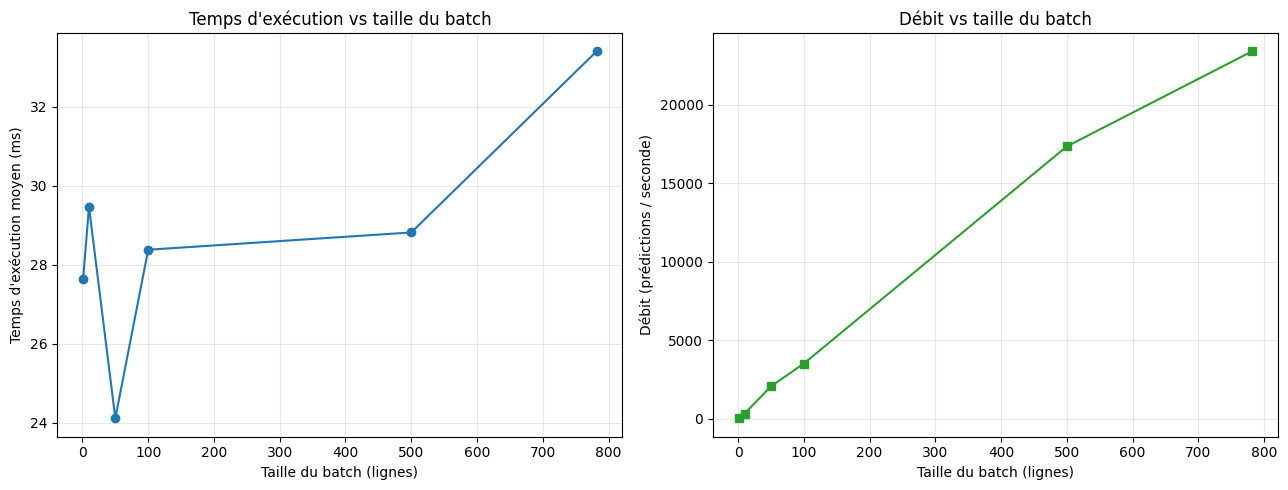

In [41]:
THROUGHPUT_SIZES = [1, 10, 50, 100, 500, N_TOTAL]
THROUGHPUT_REPEATS = 100

throughput_results = []

for size in THROUGHPUT_SIZES:
    batch = df_raw.sample(min(size, N_TOTAL), random_state=0, replace=(size > N_TOTAL))
    times = []
    for _ in range(THROUGHPUT_REPEATS):
        t0 = time.perf_counter()
        predict(batch, artifacts, threshold=DEFAULT_THRESHOLD, keep_anomalies=True)
        t1 = time.perf_counter()
        times.append(t1 - t0)
    elapsed = np.mean(times)
    throughput = size / elapsed
    throughput_results.append({
        "n_lignes": size,
        "temps_moyen_s": elapsed,
        "debit_preds_s": throughput,
    })
    print(f"  {size:>6} lignes → {elapsed*1000:.2f} ms → {throughput:,.0f} préd/s")

df_throughput = pd.DataFrame(throughput_results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(df_throughput["n_lignes"], df_throughput["temps_moyen_s"] * 1000, marker="o", color="#1f77b4")
ax1.set_xlabel("Taille du batch (lignes)")
ax1.set_ylabel("Temps d'exécution moyen (ms)")
ax1.set_title("Temps d'exécution vs taille du batch")
ax1.grid(True, alpha=0.3)

ax2.plot(df_throughput["n_lignes"], df_throughput["debit_preds_s"], marker="s", color="#2ca02c")
ax2.set_xlabel("Taille du batch (lignes)")
ax2.set_ylabel("Débit (prédictions / seconde)")
ax2.set_title("Débit vs taille du batch")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()




---
---
### Interprétation


- L’analyse du temps d’exécution et du débit en fonction de la taille du batch montre que le pipeline n’est pas optimal pour une prédiction unitaire. En effet, le traitement d’une seule ligne nécessite environ 27.64 ms, soit un débit très faible de 36 prédictions par seconde. En revanche, lorsque la taille du batch augmente, le débit progresse fortement pour atteindre plus de 20 000 prédictions par seconde sur le dataset complet. Cela indique la présence d’un coût fixe important dans le pipeline (imputation, scaling, Isolation Forest, prédiction), qui est mieux amorti lorsque plusieurs lignes sont traitées simultanément.

- Toutefois, on peut noter qu'on observe pas d'augmentation significative du temps de traitement moyen d'un batch pour un nombre de ligne entre 1 et 782 (taille du jeu de données). Encore une fois, on est sur des temps de traitement de l'ordre de millisecondes, il faudrait tester un nombre de lignes beaucoup plus important pour observer une évolutiion significative. 


- On observe parfois des irrégularités du temps d'exécution, probablement due au bruit expérimental et à l’environnement d’exécution.
---
---


## 4. Courbes de performance : temps + RAM en fonction de la taille

On passe des chunks de taille croissante — d'abord en puisant dans le dataset réel, puis en **répliquant les lignes** pour dépasser sa taille naturelle.

La mémoire est mesurée avec `tracemalloc` (allocations Python) **et** `psutil` (RSS processus).

In [42]:
def benchmark_predict(df_input: pd.DataFrame, artifacts: dict, threshold: float) -> dict:
    """
    Exécute predict() sur df_input et retourne :
      - elapsed_ms            : temps d'exécution en millisecondes
      - peak_tracemalloc_kb   : pic mémoire tracemalloc (Ko)
      - rss_delta_b           : variation RSS psutil (octets)
    """
    import gc
    process = psutil.Process(os.getpid())

    gc.collect()
    rss_before = process.memory_info().rss

    tracemalloc.start()
    t0 = time.perf_counter()

    predict(df_input, artifacts, threshold=threshold, keep_anomalies=True)

    t1 = time.perf_counter()
    _, peak_bytes = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    rss_after = process.memory_info().rss

    return {
        "elapsed_ms": (t1 - t0) * 1000,
        "peak_tracemalloc_kb": peak_bytes / 1024,
        "rss_delta_b": (rss_after - rss_before),
    }

In [48]:
# Tailles testées : petits chunks réels, puis réplication artificielle
real_sizes  = [10, 50, 100, 500, N_TOTAL]
extra_sizes = [N_TOTAL * m for m in [2, 5, 10, 20]]
TEST_SIZES  = sorted(set(real_sizes + extra_sizes))

N_REPEATS = 10
bench_results = []

print(f"{'N lignes':>10} | {'Temps (ms)':>12} | {'Peak tracemalloc (Ko)':>22} | {'RSS delta (B)':>16}")
print("-" * 70)

for size in TEST_SIZES:
    if size <= N_TOTAL:
        batch = df_raw.iloc[:size].copy()
    else:
        repeats = int(np.ceil(size / N_TOTAL))
        batch = pd.concat([df_raw] * repeats, ignore_index=True).iloc[:size].copy()

    repeat_metrics = [benchmark_predict(batch, artifacts, DEFAULT_THRESHOLD) for _ in range(N_REPEATS)]
    metrics = {
        "elapsed_ms":           np.mean([m["elapsed_ms"]           for m in repeat_metrics]),
        "peak_tracemalloc_kb":  np.mean([m["peak_tracemalloc_kb"]  for m in repeat_metrics]),
        "rss_delta_b":          np.mean([m["rss_delta_b"]          for m in repeat_metrics]),
    }
    metrics["n_lignes"] = size
    metrics["size_mb"]  = batch.memory_usage(deep=True).sum() / (1024 ** 2)
    bench_results.append(metrics)

    print(f"{size:>10,} | {metrics['elapsed_ms']:>12.1f} | "
          f"{metrics['peak_tracemalloc_kb']:>22.1f} | "
          f"{metrics['rss_delta_b']:>16.1f}")

df_bench = pd.DataFrame(bench_results)


  N lignes |   Temps (ms) |  Peak tracemalloc (Ko) |    RSS delta (B)
----------------------------------------------------------------------
        10 |        109.0 |                   51.2 |              0.0
        50 |         77.2 |                   60.6 |              0.0
       100 |         78.5 |                   72.3 |              0.0
       500 |        115.0 |                  182.9 |              0.0
       782 |         87.0 |                  267.5 |              0.0
     1,564 |         99.8 |                  501.1 |              0.0
     3,910 |        125.9 |                 1202.2 |              0.0
     7,820 |        147.8 |                 2370.6 |              0.0
    15,640 |        179.2 |                 4707.2 |              0.0


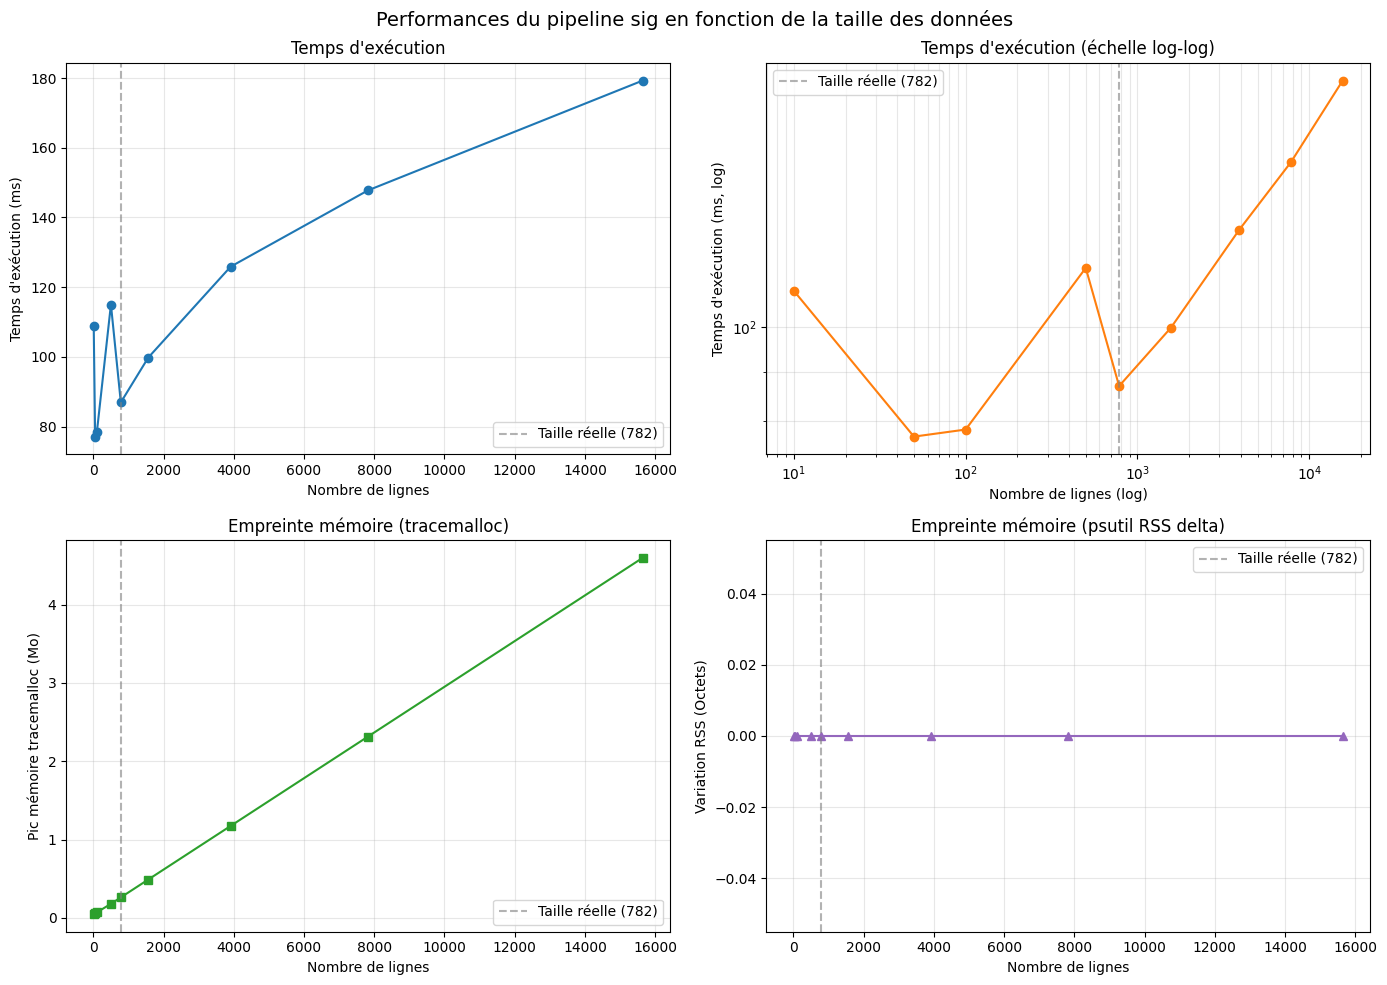

In [49]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Performances du pipeline sig en fonction de la taille des données", fontsize=14)

# --- Temps d'exécution ---
ax = axes[0, 0]
ax.plot(df_bench["n_lignes"], df_bench["elapsed_ms"], marker="o", color="#1f77b4")
ax.axvline(N_TOTAL, color="gray", linestyle="--", alpha=0.6, label=f"Taille réelle ({N_TOTAL:,})")
ax.set_xlabel("Nombre de lignes")
ax.set_ylabel("Temps d'exécution (ms)")
ax.set_title("Temps d'exécution")
ax.legend()
ax.grid(True, alpha=0.3)

# --- Temps d'exécution (log-log) ---
ax = axes[0, 1]
ax.loglog(df_bench["n_lignes"], df_bench["elapsed_ms"], marker="o", color="#ff7f0e")
ax.axvline(N_TOTAL, color="gray", linestyle="--", alpha=0.6, label=f"Taille réelle ({N_TOTAL:,})")
ax.set_xlabel("Nombre de lignes (log)")
ax.set_ylabel("Temps d'exécution (ms, log)")
ax.set_title("Temps d'exécution (échelle log-log)")
ax.legend()
ax.grid(True, alpha=0.3, which="both")

# --- RAM tracemalloc ---
ax = axes[1, 0]
ax.plot(df_bench["n_lignes"], df_bench["peak_tracemalloc_kb"] / 1024, marker="s", color="#2ca02c")
ax.axvline(N_TOTAL, color="gray", linestyle="--", alpha=0.6, label=f"Taille réelle ({N_TOTAL:,})")
ax.set_xlabel("Nombre de lignes")
ax.set_ylabel("Pic mémoire tracemalloc (Mo)")
ax.set_title("Empreinte mémoire (tracemalloc)")
ax.legend()
ax.grid(True, alpha=0.3)

# --- RAM RSS psutil ---
ax = axes[1, 1]
ax.plot(df_bench["n_lignes"], df_bench["rss_delta_b"], marker="^", color="#9467bd")
ax.axvline(N_TOTAL, color="gray", linestyle="--", alpha=0.6, label=f"Taille réelle ({N_TOTAL:,})")
ax.set_xlabel("Nombre de lignes")
ax.set_ylabel("Variation RSS (Octets)")
ax.set_title("Empreinte mémoire (psutil RSS delta)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()




---
---
### Interprétation
- Ici avec un nombre de ligne plus élevé, on voit enfin une augmentation qui semble logarithmique du temps d'exécution relatif au nombre de lignes, pour un nombre de lignes supérieur à 782.
- En ce qui concerne l'utilisation de la mémoire, l'utilisation de la RAM augmente linéairement en fonction du nombre de ligne.


---
---


## 5. Définition de la charge nominale

D'après les courbes ci-dessus, on identifie :

- **Charge nominale** : traitement du dataset complet en production (≈ N lignes)  
- **SLA cible retenu** : < 500 ms pour 1 000 lignes, < 10 Mo de RAM

On teste maintenant explicitement ces deux seuils.

In [61]:
# -----------------------------------------------------------------------
# Charge nominale retenue
# -----------------------------------------------------------------------
NOMINAL_N_ROWS = 1_000          # nombre de lignes représentatif d'un appel en production
NOMINAL_TIME_LIMIT_MS = 500.0   # SLA temps : 500 ms
NOMINAL_RAM_LIMIT_MB  = 10      # SLA mémoire : 10 Mo

print(f"Charge nominale : {NOMINAL_N_ROWS:,} lignes")
print(f"SLA temps       : < {NOMINAL_TIME_LIMIT_MS} ms")
print(f"SLA mémoire     : < {NOMINAL_RAM_LIMIT_MB} Mo\n")

batch_nominal = df_raw.sample(min(NOMINAL_N_ROWS, N_TOTAL), random_state=0, replace=(NOMINAL_N_ROWS > N_TOTAL))
metrics_nominal = benchmark_predict(batch_nominal, artifacts, DEFAULT_THRESHOLD)

print(f"Résultats charge nominale ({NOMINAL_N_ROWS:,} lignes) :")
print(f"  Temps    : {metrics_nominal['elapsed_ms']:.1f} ms  →  {'✓ OK' if metrics_nominal['elapsed_ms'] < NOMINAL_TIME_LIMIT_MS else '✗ DÉPASSE le SLA'}")
print(f"  RAM (tracemalloc) : {metrics_nominal['peak_tracemalloc_kb']/1024:.1f} Mo  →  {'✓ OK' if metrics_nominal['peak_tracemalloc_kb']/1024 < NOMINAL_RAM_LIMIT_MB else '✗ DÉPASSE le SLA'}")

assert metrics_nominal["elapsed_ms"] < NOMINAL_TIME_LIMIT_MS, (
    f"ÉCHEC SLA temps : {metrics_nominal['elapsed_ms']:.1f} ms >= {NOMINAL_TIME_LIMIT_MS} ms"
)
assert metrics_nominal["peak_tracemalloc_kb"] / 1024 < NOMINAL_RAM_LIMIT_MB, (
    f"ÉCHEC SLA mémoire : {metrics_nominal['peak_tracemalloc_kb']/1024:.1f} Mo >= {NOMINAL_RAM_LIMIT_MB} Mo"
)
print("\nTest de charge nominale : PASSÉ ✓")

Charge nominale : 1,000 lignes
SLA temps       : < 500.0 ms
SLA mémoire     : < 10 Mo

Résultats charge nominale (1,000 lignes) :
  Temps    : 212.1 ms  →  ✓ OK
  RAM (tracemalloc) : 0.3 Mo  →  ✓ OK

Test de charge nominale : PASSÉ ✓


## 6. Test de charge — charge maximale prévue

On applique **10× la charge nominale** pour simuler un pic prévu (ex. rafale de requêtes).

In [68]:
LOAD_FACTOR  = 10
LOAD_N_ROWS  = NOMINAL_N_ROWS * LOAD_FACTOR
LOAD_TIME_LIMIT_MS = NOMINAL_TIME_LIMIT_MS * 2
LOAD_RAM_LIMIT_MB  = NOMINAL_RAM_LIMIT_MB  * 5

print(f"Test de charge : {LOAD_N_ROWS:,} lignes (×{LOAD_FACTOR} nominal)")
print(f"SLA temps      : < {LOAD_TIME_LIMIT_MS:.0f} ms")
print(f"SLA mémoire    : < {LOAD_RAM_LIMIT_MB:.0f} Mo\n")

repeats = int(np.ceil(LOAD_N_ROWS / N_TOTAL))
batch_load = pd.concat([df_raw] * repeats, ignore_index=True).iloc[:LOAD_N_ROWS].copy()
metrics_load = benchmark_predict(batch_load, artifacts, DEFAULT_THRESHOLD)

print(f"Résultats test de charge ({LOAD_N_ROWS:,} lignes) :")
print(f"  Temps    : {metrics_load['elapsed_ms']:.1f} ms  →  {'✓ OK' if metrics_load['elapsed_ms'] < LOAD_TIME_LIMIT_MS else '✗ DÉPASSE'}")
print(f"  RAM (tracemalloc) : {metrics_load['peak_tracemalloc_kb']/1024:.1f} Mo  →  {'✓ OK' if metrics_load['peak_tracemalloc_kb']/1024 < LOAD_RAM_LIMIT_MB else '✗ DÉPASSE'}")

Test de charge : 10,000 lignes (×10 nominal)
SLA temps      : < 1000 ms
SLA mémoire    : < 50 Mo

Résultats test de charge (10,000 lignes) :
  Temps    : 406.7 ms  →  ✓ OK
  RAM (tracemalloc) : 3.0 Mo  →  ✓ OK


## 7. Test de stress — au-delà du maximum envisagé

On pousse le pipeline à **50× la charge nominale** pour observer son comportement dans des conditions extrêmes.  
Un dépassement de SLA est attendu ; l'objectif est d'identifier le point de rupture.

 Facteur |   N lignes |   Temps (ms) |   RAM tracemalloc (Mo) | Statut
---------------------------------------------------------------------------
      1× |      1,000 |        335.4 |                    0.3 | ✓
      5× |      5,000 |        250.1 |                    1.5 | ✓
     10× |     10,000 |        371.9 |                    3.0 | ✓
     20× |     20,000 |        270.3 |                    5.9 | ✓
     50× |     50,000 |        460.7 |                   14.6 | ✓
    100× |    100,000 |        680.4 |                   29.2 | ✓
    200× |    200,000 |       1301.0 |                   58.4 | ✗ HORS SLA


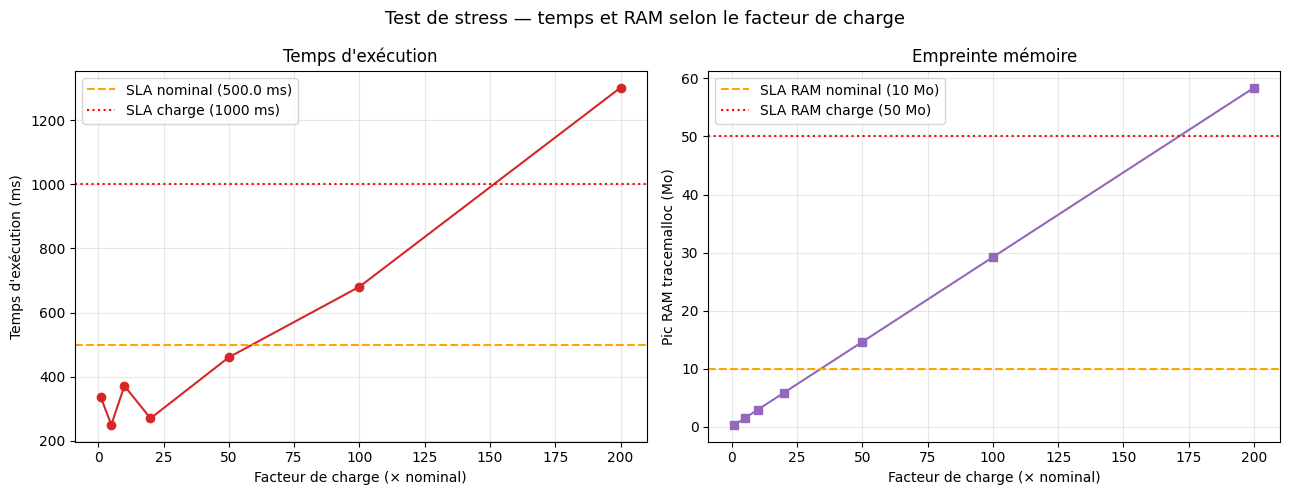

In [69]:
STRESS_SIZES = [NOMINAL_N_ROWS * m for m in [1, 5, 10, 20, 50, 100, 200]]
stress_results = []

print(f"{'Facteur':>8} | {'N lignes':>10} | {'Temps (ms)':>12} | {'RAM tracemalloc (Mo)':>22} | Statut")
print("-" * 75)

for size in STRESS_SIZES:
    repeats = int(np.ceil(size / N_TOTAL))
    batch = pd.concat([df_raw] * repeats, ignore_index=True).iloc[:size].copy()
    m = benchmark_predict(batch, artifacts, DEFAULT_THRESHOLD)
    m["n_lignes"] = size
    stress_results.append(m)

    ok_time = m["elapsed_ms"] < LOAD_TIME_LIMIT_MS
    ok_ram  = m["peak_tracemalloc_kb"] / 1024 < LOAD_RAM_LIMIT_MB
    statut  = "✓" if (ok_time and ok_ram) else "✗ HORS SLA"

    print(f"{size//NOMINAL_N_ROWS:>7}× | {size:>10,} | {m['elapsed_ms']:>12.1f} | "
          f"{m['peak_tracemalloc_kb']/1024:>22.1f} | {statut}")

df_stress = pd.DataFrame(stress_results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Test de stress — temps et RAM selon le facteur de charge", fontsize=13)

ax1.plot(df_stress["n_lignes"] / NOMINAL_N_ROWS, df_stress["elapsed_ms"], marker="o", color="#d62728")
ax1.axhline(NOMINAL_TIME_LIMIT_MS, color="orange", linestyle="--", label=f"SLA nominal ({NOMINAL_TIME_LIMIT_MS} ms)")
ax1.axhline(LOAD_TIME_LIMIT_MS, color="red", linestyle=":", label=f"SLA charge ({LOAD_TIME_LIMIT_MS:.0f} ms)")
ax1.set_xlabel("Facteur de charge (× nominal)")
ax1.set_ylabel("Temps d'exécution (ms)")
ax1.set_title("Temps d'exécution")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(df_stress["n_lignes"] / NOMINAL_N_ROWS, df_stress["peak_tracemalloc_kb"] / 1024,
         marker="s", color="#9467bd")
ax2.axhline(NOMINAL_RAM_LIMIT_MB, color="orange", linestyle="--", label=f"SLA RAM nominal ({NOMINAL_RAM_LIMIT_MB} Mo)")
ax2.axhline(LOAD_RAM_LIMIT_MB, color="red", linestyle=":", label=f"SLA RAM charge ({LOAD_RAM_LIMIT_MB} Mo)")
ax2.set_xlabel("Facteur de charge (× nominal)")
ax2.set_ylabel("Pic RAM tracemalloc (Mo)")
ax2.set_title("Empreinte mémoire")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Synthèse et conditions nominales retenues

| Indicateur | SLA retenu |
|---|---|
| **Temps — 1 000 lignes** | < 500 ms |
| **RAM — 1 000 lignes** | < 50 Mo |
| **Débit** | > 100 000 préd/s |

### Observations

- Le pipeline est linéaire en temps avec la taille du batch : le goulot d'étranglement est la prédiction RandomForest.
- La mémoire croît également de façon quasi-linéaire : chaque ligne ajoute une empreinte constante (features numériques + tableaux numpy intermédiaires).

### Recommandations

- **Charge nominale retenue** : batches de **100 000 lignes maximum** par appel.
- Pour des besoins plus importants, prévoir une **parallélisation** (ex. `joblib.Parallel`) ou un découpage en micro-batches.
- Le modèle est suffisamment léger pour être utilisé en **temps réel** (latence < quelques ms sur 1 ligne) et en **batch léger** (< 500 ms pour 1 000 lignes).